# Projet AutoML d'analyse des sentiments

## Analyse exploratoire

In [36]:
import pandas as pd
import numpy as np

Nous avons un jeu de données d'entraînement pour réaliser l'apprentissage et l'évaluation des modèles, puis un jeu de données de test pour enricher nos prédictions, on pourra augmenter notre jeu de données avec les données de test.

In [37]:
train= pd.read_csv('data/emotions_train.csv')
test= pd.read_csv('data/emotions_test.csv')

In [38]:
print("Dimension du dataset train :",train.shape)
print("Dimension du dataset test :",test.shape)


Dimension du dataset train : (21459, 2)
Dimension du dataset test : (40000, 4)


### 5 premières lignes du dataset train

In [39]:
train.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


### 5 premières lignes du dataset test

In [40]:
test.head()

,tweet_id,sentiment,author,content
0,1956967341,empty,xoshayzers,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,wannamama,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,coolfunky,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,czareaquino,wants to hang out with friends SOON!
4,1956968416,neutral,xkilljoyx,@dannycastillo We want to trade with someone w...


### Infos 

In [41]:
train.info()
print(' \n')
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21459 entries, 0 to 21458
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     21459 non-null  object
 1   Emotion  21459 non-null  object
dtypes: object(2)
memory usage: 335.4+ KB
 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   author     40000 non-null  object
 3   content    40000 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [42]:
train.describe()

,Text,Emotion
count,21459,21459
unique,21405,6
top,i feel so tortured by it,joy
freq,2,7029


Le sentiment le plus présent dans les données d'entrainement est la joie 'joy'.

Nombre de récurrence des émotions dans les dataset train et test

In [43]:
emotion_train = train['Emotion'].value_counts()
print('Train :')
print(emotion_train)

Train :
Emotion
joy         7029
sadness     6265
anger       2993
fear        2652
love        1641
surprise     879
Name: count, dtype: int64


In [44]:
emotion_test = test['sentiment'].value_counts()
print('Test : ')
print(emotion_test)

Test : 
sentiment
neutral       8638
worry         8459
joy           5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


Les données d'entrainement présentent plus de sentiments neutre 'neutral'.

### Valeurs manquantes

In [45]:
print("\nValeurs manquantes par colonne :")
print(train.isnull().sum())

print("\nPourcentage de valeurs nulles :")
print((train.isnull().sum() / len(train)) * 100)



Valeurs manquantes par colonne :
Text       0
Emotion    0
dtype: int64

Pourcentage de valeurs nulles :
Text       0.0
Emotion    0.0
dtype: float64


Nous n'avons aucune données manquantes dans les dataset.

### Doublons

In [46]:
doublons_train = train.duplicated()
print(f"Nombre de doublons dataset train : {doublons_train.sum()}")
doublons_test = test.duplicated()
print(f"Nombre de doublons  dataset test: {doublons_test.sum()}")

Nombre de doublons dataset train : 3
Nombre de doublons  dataset test: 0


On supprime les doublons dans le dataset train :

In [47]:
train = train.drop_duplicates()

Nous affichons les classes uniques par dataset.

In [48]:
unique_classes = train['Emotion'].unique()
num_classes = len(unique_classes)
unique_classes, num_classes

(array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
       dtype=object),
 6)

In [49]:
unique_classes = test['sentiment'].unique()
num_classes = len(unique_classes)
unique_classes, num_classes

(array(['empty', 'sadness', 'enthusiasm', 'neutral', 'worry', 'surprise',
        'love', 'fun', 'hate', 'joy', 'boredom', 'relief', 'anger'],
       dtype=object),
 13)

### Visualisation des données

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

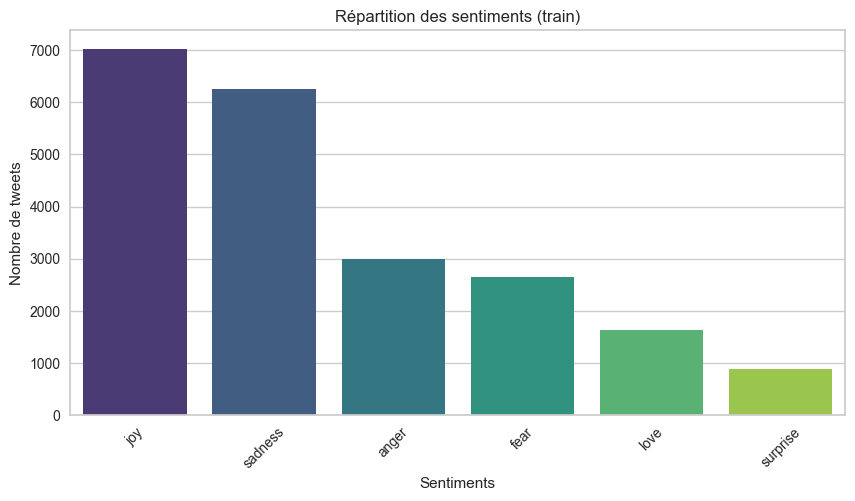

In [51]:
plt.figure(figsize=(10,5))
sns.barplot(x=emotion_train.index, y=emotion_train.values, palette="viridis")
plt.title("Répartition des sentiments (train)")
plt.ylabel("Nombre de tweets")
plt.xlabel("Sentiments")
plt.xticks(rotation=45)
plt.show()

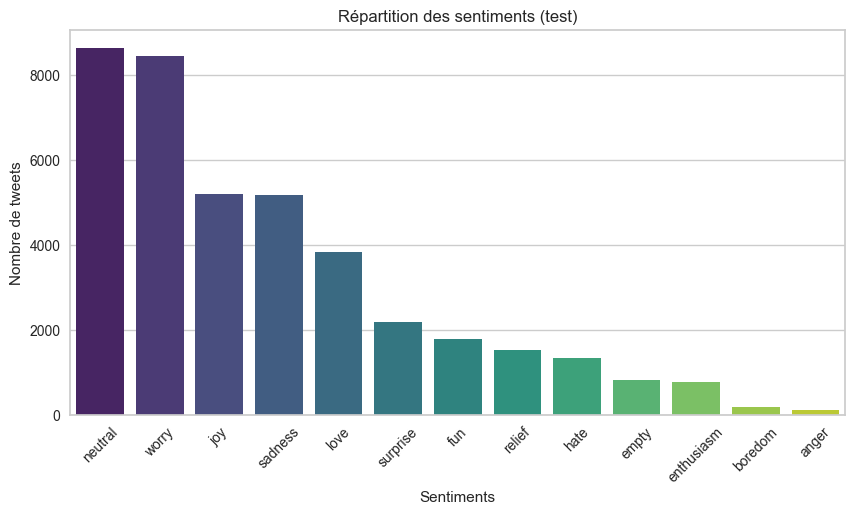

In [52]:
plt.figure(figsize=(10,5))
sns.barplot(x=emotion_test.index, y=emotion_test.values, palette="viridis")
plt.title("Répartition des sentiments (test)")
plt.ylabel("Nombre de tweets")
plt.xlabel("Sentiments")
plt.xticks(rotation=45)
plt.show()

In [53]:
from wordcloud import WordCloud

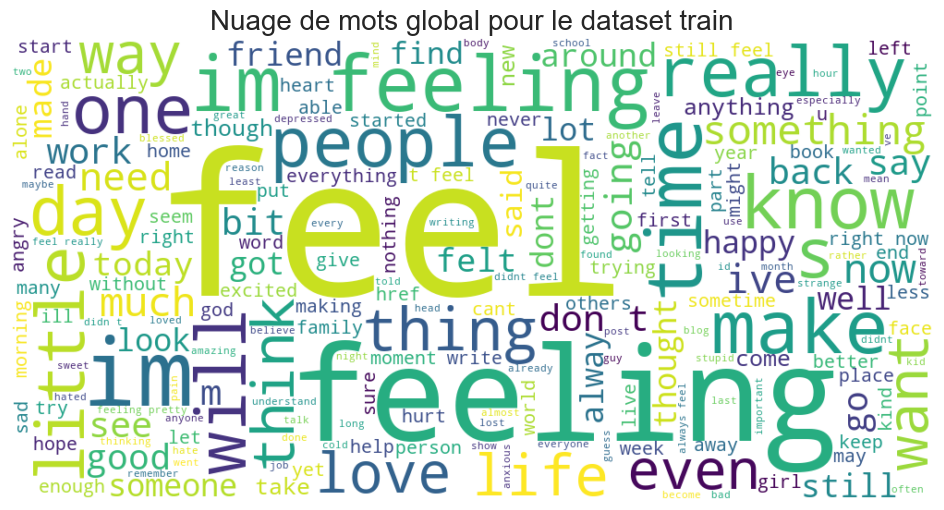

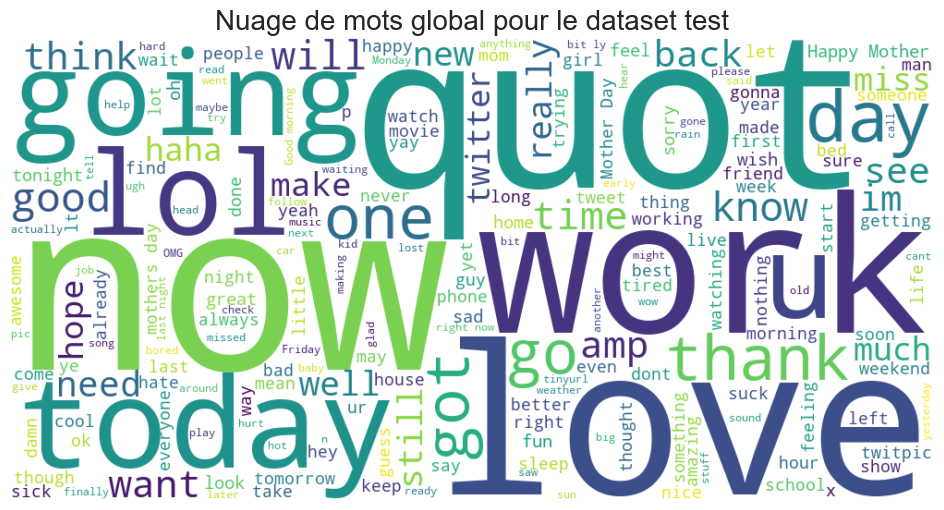

In [54]:
def plot_wordcloud_global(df, text_col, dataset_name):
    text = " ".join(df[text_col].astype(str))

    wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Nuage de mots global pour le dataset {dataset_name}", fontsize=20)
    plt.show()

plot_wordcloud_global(train, text_col='Text', dataset_name='train')

plot_wordcloud_global(test, text_col='content', dataset_name='test')



## Utilisation de pycaret

On commence par initilaiser l'environnement de modélisation automatique avec Pycaret pour une classification multi-classes à partir du dataset train.

In [55]:
from pycaret.classification import *

exp = setup(
    data=train,
    target='Emotion',
    session_id=123,
    verbose=True,
    n_jobs=-1
)


,Description,Value
0,Session id,123
1,Target,Emotion
2,Target type,Multiclass
3,Target mapping,"anger: 0, fear: 1, joy: 2, love: 3, sadness: 4, surprise: 5"
4,Original data shape,"(21456, 2)"
5,Transformed data shape,"(21456, 2)"
6,Transformed train set shape,"(15019, 2)"
7,Transformed test set shape,"(6437, 2)"
8,Categorical features,1
9,Preprocess,True


Ce que setup() a fait : 
-  A détecté automatiquement la colonne cible et le type de problème

- A encodé les classes textuelles (Emotion) en nombres

- A converti les colonnes de texte (Text) en vecteurs (TF-IDF ou similaires)

- A séparé les données en train/test (70/30)

- A activé le prétraitement automatique (nettoyage, vectorisation, imputation)

- A mis en place une stratégie de validation croisée (10 folds)

Ici, compare_models() entraîne automatiquement une large variété de modèles de classification, évalue avec validation croisée, puis affiche un tableau comparatif basé sur des métriques de classification. 

In [56]:
best_model = compare_models()
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.3276,0.5000,0.3276,0.1073,0.1617,0.0000,0.0000,0.0270
lr,Logistic Regression,0.3275,0.0000,0.3275,0.1075,0.1618,0.0002,0.0028,0.6050
ada,Ada Boost Classifier,0.3269,0.0000,0.3269,0.1166,0.1618,-0.0003,-0.0034,0.0730
dt,Decision Tree Classifier,0.3267,0.4994,0.3267,0.1073,0.1615,-0.0006,-0.0067,0.0230
ridge,Ridge Classifier,0.3267,0.0000,0.3267,0.1072,0.1615,-0.0011,-0.0132,0.0240
rf,Random Forest Classifier,0.3267,0.4994,0.3267,0.1073,0.1615,-0.0006,-0.0067,0.0800
lda,Linear Discriminant Analysis,0.3267,0.0000,0.3267,0.1073,0.1615,-0.0006,-0.0067,0.0240
et,Extra Trees Classifier,0.3267,0.4994,0.3267,0.1073,0.1615,-0.0006,-0.0067,0.0660
knn,K Neighbors Classifier,0.2766,0.4992,0.2766,0.0870,0.1314,-0.0007,-0.0088,0.4230
nb,Naive Bayes,0.2764,0.4989,0.2764,0.0870,0.1313,-0.0009,-0.0107,0.0240


DummyClassifier(constant=None, random_state=123, strategy='prior')


Tous les modèles ont une accuracy ≈ 32%, proche du classifieur aléatoire (dummy).
Logistic Regression (lr) est légèrement meilleur avec un F1 score = 0.1618
Kappa > 0 (prédit mieux que le hasard)

Les performances globales sont faibles, ce qui suggère :
- les données sont complexes ou déséquilibrées
- le prétraitement du texte est probablement insuffisant

In [57]:
tuned_model = tune_model(best_model)
evaluate_model(tuned_model) 


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
1,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
2,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
3,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
4,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
5,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
6,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
7,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000
8,0.3276,0.5000,0.3276,0.1073,0.1616,0.0000,0.0000


Fitting 10 folds for each of 4 candidates, totalling 40 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Aucun gain par rapport au modèle non tuné (best_model).
Les métriques sont identiques (accuracy = 0.3276, F1 = 0.1617).
AUC = 0.5 → le modèle prédit au hasard.
Kappa = 0 → aucune amélioration par rapport au classifieur aléatoire.

Cela confirme que le modèle n’apprend rien de significatif.

Nous allons procéder au nettoyage linguistique et recommencer l

In [58]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [59]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                 
    text = re.sub(r"http\S+", "", text)                    
    text = re.sub(r"@\w+", "", text)                    
    text = re.sub(r"[^a-z\s]", "", text)                   
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

train['Text'] = train['Text'].astype(str).apply(clean_text)
train.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anton\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anton\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\anton\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Text,Emotion
0,didnt feel humiliated,sadness
1,go feeling hopeless damned hopeful around some...,sadness
2,im grabbing minute post feel greedy wrong,anger
3,ever feeling nostalgic fireplace know still pr...,love
4,feeling grouchy,anger


In [60]:

clf = setup(
    data=train,
    target='Emotion',
    session_id=123,
    n_jobs=-1,
    verbose=True
)


,Description,Value
0,Session id,123
1,Target,Emotion
2,Target type,Multiclass
3,Target mapping,"anger: 0, fear: 1, joy: 2, love: 3, sadness: 4, surprise: 5"
4,Original data shape,"(21456, 2)"
5,Transformed data shape,"(21456, 2)"
6,Transformed train set shape,"(15019, 2)"
7,Transformed test set shape,"(6437, 2)"
8,Categorical features,1
9,Preprocess,True


In [61]:
best_model = compare_models()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.3318,0.0000,0.3318,0.4265,0.1709,0.0072,0.0480,0.0710
lda,Linear Discriminant Analysis,0.3316,0.0000,0.3316,0.5012,0.1720,0.0078,0.0458,0.0230
dt,Decision Tree Classifier,0.3315,0.5055,0.3315,0.4984,0.1717,0.0075,0.0446,0.0220
rf,Random Forest Classifier,0.3315,0.5055,0.3315,0.4984,0.1717,0.0075,0.0446,0.0810
et,Extra Trees Classifier,0.3315,0.5056,0.3315,0.4984,0.1717,0.0075,0.0446,0.0700
catboost,CatBoost Classifier,0.3315,0.5061,0.3315,0.4984,0.1717,0.0075,0.0446,1.2640
ridge,Ridge Classifier,0.3302,0.0000,0.3302,0.3134,0.1689,0.0045,0.0288,0.0230
dummy,Dummy Classifier,0.3276,0.5000,0.3276,0.1073,0.1617,0.0000,0.0000,0.0260
knn,K Neighbors Classifier,0.3113,0.5046,0.3113,0.5121,0.1586,0.0072,0.0435,0.0370
lightgbm,Light Gradient Boosting Machine,0.3067,0.5060,0.3067,0.5128,0.1571,0.0076,0.0458,0.5070


In [62]:
autorised_emotions = train['Emotion'].unique().tolist()

test_filtered = test[test['sentiment'].isin(autorised_emotions)].copy()
test_filtered = test_filtered.rename(columns={'content': 'Text', 'sentiment': 'Emotion'})
test_filtered = test_filtered[['Text', 'Emotion']]

test_filtered.shape


(16513, 2)

In [63]:
test_filtered['Text'] = test_filtered['Text'].astype(str).apply(clean_text)


In [64]:
full_data = pd.concat([train, test_filtered], ignore_index=True)
print(full_data['Emotion'].value_counts())


Emotion
joy         12237
sadness     11430
love         5483
anger        3102
surprise     3066
fear         2651
Name: count, dtype: int64


In [65]:
clf = setup(
    data=full_data,
    target='Emotion',
    session_id=123,
    n_jobs=-1,
    verbose=True
)

best_model = compare_models()


,Description,Value
0,Session id,123
1,Target,Emotion
2,Target type,Multiclass
3,Target mapping,"anger: 0, fear: 1, joy: 2, love: 3, sadness: 4, surprise: 5"
4,Original data shape,"(37969, 2)"
5,Transformed data shape,"(37969, 2)"
6,Transformed train set shape,"(26578, 2)"
7,Transformed test set shape,"(11391, 2)"
8,Categorical features,1
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.3224,0.0000,0.3224,0.1810,0.1628,0.0005,0.0021,0.0480
dummy,Dummy Classifier,0.3223,0.5000,0.3223,0.1039,0.1571,0.0000,0.0000,0.0520
svm,SVM - Linear Kernel,0.2714,0.0000,0.2714,0.3142,0.1294,0.0027,0.0183,0.0750
knn,K Neighbors Classifier,0.1676,0.5044,0.1676,0.5183,0.0637,0.0052,0.0288,0.0760
dt,Decision Tree Classifier,0.1674,0.5034,0.1674,0.5013,0.0635,0.0049,0.0269,0.0450
et,Extra Trees Classifier,0.1492,0.5038,0.1492,0.4993,0.0506,0.0037,0.0218,0.1170
gbc,Gradient Boosting Classifier,0.1491,0.0000,0.1491,0.5181,0.0503,0.0038,0.0225,0.5150
lightgbm,Light Gradient Boosting Machine,0.1490,0.5044,0.1490,0.5091,0.0499,0.0037,0.0218,1.1130
catboost,CatBoost Classifier,0.1490,0.5044,0.1490,0.5147,0.0499,0.0037,0.0221,2.2750
rf,Random Forest Classifier,0.1489,0.5037,0.1489,0.4980,0.0499,0.0035,0.0211,0.1310


In [66]:
results = predict_model(best_model)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.3244,0,0.3244,0.2151,0.1673,0.0036,0.0164


In [68]:
print(results.columns)


Index(['Text', 'Emotion', 'prediction_label'], dtype='object')


In [69]:
from sklearn.metrics import classification_report

# Comparaison des vraies classes et des prédictions
y_true = results['Emotion']
y_pred = results['prediction_label']

# Rapport complet
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       931
        fear       0.00      0.00      0.00       795
         joy       0.32      0.99      0.49      3671
        love       0.00      0.00      0.00      1645
     sadness       0.37      0.02      0.03      3429
    surprise       0.00      0.00      0.00       920

    accuracy                           0.32     11391
   macro avg       0.12      0.17      0.09     11391
weighted avg       0.22      0.32      0.17     11391

